# NUMPY Basics - 你需要知道的关于Numpy的基本知识

内容条目 Table of contents

0. NumPy框架介绍（把握核心概念，通透理解设计理念）

1. NumPy ndarray构建方法

    1.1. 直接构建方法

    1.2. 从现有数据构建（含pandas DataFrame转换）

    1.3. 数组属性，数据类型

2. NumPy array 操作（manipulation）

    2.1.NumPy索引和切片（indexing and slicing）

    2.2.NumPy数学运算（arithmetic operations）

        2.3.1. NumPy Broadcasting

    2.3.NumPy统计运算（statistical functions）

    2.4. Numpy其他操作 （binary operators， string functions）

    2.5. NumPy 排序（sorting）

    2.6. NumPy searching

    2.7. Numpy arrays多个数组合并，分割，添加，删除操作

3. NumPy copies and views

4. Input output with NumPy


In [ ]:
#coding:utf-8
import numpy as np
import sys

## The NumPy ndarray: A Multidimensional Array Object

书本文档：
- b02.02_The_Basics_Of_NumPy_Arrays.ipynb


# 1.Numpy内置构建方法

提问：出行你选坐牛车还是做高铁？

Numpy提供的高效快速构建方法(高铁)：
- np数组直接生成函数：
  - np.array(), 
  - `numpy.arange(start, stop, step, dtype)`
  - `numpy.linspace(start, stop, num, endpoint, retstep, dtype)`
  - `numpy.logspace(start, stop, num, endpoint, base, dtype)`
- 随机数生成器： np.random
- 特殊矩阵：
  - np.empty()
  - np.zeros()
  - np.ones()
  - 注意：特殊矩阵中多维结构使用元组格式表达，如（2，3）
- 特色数值：np.nan
- 特色分布：np.uniform(), np.normal(), np.binomial() etc.
  

### 1.1. 使用内置数组构建方法
- np.array(list)
- list：=Python 列表 → 1维数组 ([lst])，二维或更高维的数组：嵌套列表 ([[lst1],[lst2],...])。

#### 1-d arrays (vector)

In [ ]:
arra = np.array([1,2,3,5])
# 输出显示的格式可以自由选择
print(arra)
arra

#### 2-d arrays (matrics)

In [ ]:
arrb = np.array([[2,3,4],[5,6,8]])
arrb

#### n-d arrays (tensors)

In [ ]:
arrc = np.array([[1,2,3],[4,5,6],[20,25,29]])
arrc

### 高级：从其他数据结构转换为numpy array

## 1.2. 使用np.random构建随机数组Random samples

核心概念：
- 随机种子seed
    1.	伪随机数生成原理
计算机生成的随机数基于确定性算法，称为伪随机数生成器（PRNG）。给定相同的初始种子，算法将生成相同的随机数序列。种子是生成随机数序列的起点。
    2.	种子的作用
        - 是PRNG运算的初始点
        - 可复现性：通过固定种子，确保每次运行程序生成的随机序列一致，便于调试和验证实验结果。
        - 控制随机性：在需要不同随机性的场景下，通过改变种子生成不同的数据变体。
        - 不同种子都必须满足同样的统计特性：=只改变序列，不改变统计特征

- 随机数生成:
  - 底层原理
  - 数据科学中的运用场景

方法：
- 掌握基础类型的随机数生成方法（包含数据类型+数组结构一站式生成）
  - randint()
  - rand()
- 了解利用随机数生成方法构建基本概率分布:
  - Normal deistribution: normal()
  - Binominal distribution: binomial()
  - Uniform distribution: uniform()

### 1.3. Numpy内置特色数值 np.nan

基础认知：
- Numpy数组中描述和处理数值型缺失数据的“最优选择”。 np.nan是NumPy中表示数值型缺失数据的特殊浮点值（Not a Number），专为科学计算设计
- 本身的数据类型是浮点数 (np.float64 --> 8bytes)
- 好处：非常容易和方便数据处理，如运算和判别，无需额外剔除清理

np.nan的操作：
  - 检测方法： np.isnan(arr)
  - 清洗和填充：np.where(np.isnan(arr), 0, arr)  # nan --> 0
- 
np.nan的运算：
  - 统计总数： np.isnan(arr).sum()
  - 忽略nan求和：np.nansum()
  - 忽略nan求均值： np.nanmean()
  - 忽略nan求最大最小值：np.nanmax(), np.nanmin()
  - 忽略nan求中位数：np.nanpercentile()


## 1.4. np.array attributes （np数组的属性）
理解np.array的最重要的属性，并学会查看和利用这些属性更改数组属性
- arr.ndim: 维度数
- arr.shape：维度结构
- arr.itemsize: 元素存储长度 bytes
- arr.dtype: 元素数据类型
- arr.size: 数组元素总数
  
注意：因为是属性描述，所以调用时不要加（）

In [ ]:
print(arra.itemsize)
print(arrb.dtype)
print(arrc.ndim)
arrc.shape

## 2. 数组操作

从核心概念“数据结构+操作”出发，你应该可以透彻理解“操作”的概念会是要做什么：
- 查询数组元素内容（查数值）：单个，区域，全域 → 索引方法
- 改变数值属性：结构形状，数据类型等
- 改变数值元素内容和顺序：
  - 添加，删减
  - 排序
  - 数学运算

### 2.1. 查询=索引数组，更改数组（元素，行，列，形状）

In [ ]:
a = np.array([[2,36,8,9,45],[7,5,23,89,67],[20,45,88,25,96]])
a[(0,0)]   # 访问数组的第一个元素, tuple形式(), list形式[]都可以: [0,0] 或 [0][0] 都可以访问
print(a[0][0])

In [ ]:
#get a specific row
print(a[0])   # 第一行 =  a[0, :]
print(a[1])

### 2.1.2 变形金刚（魔法：使用np数组的属性定义改变数组属性）
- 维度更改： arr.shape → arr.reshape():  改变数组形状而不更改数据（个数）
- 转换数据类型：arr.dtype → arr.astype('dtype'), np.array(arra, dtype ='dtype')

In [ ]:
print(arra.dtype)
# 挖个坑：
# 将数组数据类型转换为float32但不改变原数组
print(arra.astype('float32').dtype)
print(arra.dtype)
# 改变原数组类型 = 创建新数组
arra_ch=np.array(arra, dtype = 'float32')
print(arra_ch.dtype)

In [ ]:
print(arrc.shape)
print(arrc.reshape(1,9))

In [ ]:
#get a specific column
a[:,0]

In [ ]:
a[:,3]

In [ ]:
#get a specific element
a[1,2] #[row,col]

In [ ]:
a[0,-1]

In [ ]:
#get a sub array
a[0:2,:2]

In [ ]:
a[:2,3:]

In [ ]:
# Assigning
print(a[1,4])
a[1,4]=199
print(a[1,4])
a

### 2.2. 数学运算 Math functions

In [ ]:
a = np.array([1,2,3,5])
a

In [ ]:
a+100

In [ ]:
a #majic

In [ ]:
a-2

In [ ]:
a*10

In [ ]:
a/2

In [ ]:
a%2

In [ ]:
a//2

In [ ]:
a+a

In [ ]:
a**2

In [ ]:
np.sin(a)

In [ ]:
np.cos(a)

In [ ]:
np.tan(a)

In [ ]:
9**0.5

In [ ]:
p=np.array([1,20,44,88,45,98,200,45,345,98])
p

In [ ]:
np.min(p)

In [ ]:
np.max(p)

In [ ]:
b = np.array([[23,45,67],[78,200,46]])
b

In [ ]:
np.max(b)

In [ ]:
np.min(b)

In [ ]:
np.sum(b)

##  2.3.NumPy统计运算（statistical functions）

统计学基本概念：
- 均值: np.mean()
- 中值: np.median()
- 最大/最小值: np.min(), np.max() / np.amin(), np.amax()
- 标准差: np.std()
- 协方差: np.var()
- 正态分布: 
- 正态分布偏差衡量指标：
  - Skewness：偏度（非对称度偏差，3阶）
  - Kurtosis： 峰度（尖峰程度，4阶）

注释：
Python第三方库scipy.stats能提供（更好）的统计计算函数. 

from scipy import stats

# vertically stacking vectors

In [ ]:
v1 = np.array([1,2,3,4])
v2 = np.array([5,6,7,8])

np.vstack([v1,v2,v2,v1])

In [ ]:
#Horizantal stacks

In [ ]:
h1 = np.zeros((2,4))
h2 = np.zeros((2,2))


print(h1)
print(h2)
print('\n')
np.hstack((h1,h2))

##  Comparisions

In [ ]:
a = np.array([[1,2,48,67],[39,3,5,89]])
a

In [ ]:
print(a >50)

In [ ]:
print(a<10)

#  5 min Numpy

In [ ]:
a = np.empty(5)
a


In [ ]:
b = np.linspace(1,5) #low-high
b

In [ ]:
b = np.linspace(1,10,10) #low,high,count
b

## 矩阵运算和图像处理

In [5]:
from skimage import io

xf_im = io.imread('msd20.jpg')
jobs = io.imread('steve.jpg')
type(jobs)

numpy.ndarray

In [6]:
print(xf_im.shape)
print(jobs.shape)
#rows,columsn,color:RGB

(4032, 3024, 3)
(800, 1200, 3)


In [7]:
xf_im

array([[[ 55,  30,  10],
        [ 53,  28,   8],
        [ 53,  28,   8],
        ...,
        [212, 177, 135],
        [213, 178, 136],
        [213, 178, 136]],

       [[ 57,  32,  12],
        [ 54,  29,   9],
        [ 51,  26,   6],
        ...,
        [213, 178, 136],
        [214, 179, 137],
        [214, 179, 137]],

       [[ 58,  33,  13],
        [ 54,  29,   9],
        [ 48,  22,   5],
        ...,
        [214, 179, 137],
        [214, 179, 137],
        [213, 178, 136]],

       ...,

       [[116, 112, 111],
        [113, 109, 108],
        [111, 107, 106],
        ...,
        [102,  81,  88],
        [104,  81,  89],
        [103,  82,  89]],

       [[113, 112, 110],
        [112, 111, 109],
        [111, 110, 108],
        ...,
        [105,  86,  92],
        [107,  86,  93],
        [104,  85,  91]],

       [[112, 111, 109],
        [114, 113, 111],
        [115, 114, 112],
        ...,
        [109,  90,  96],
        [111,  92,  98],
        [109,  90,  96]]

Text(0.5, 1.0, '范公风范-先天下之忧')

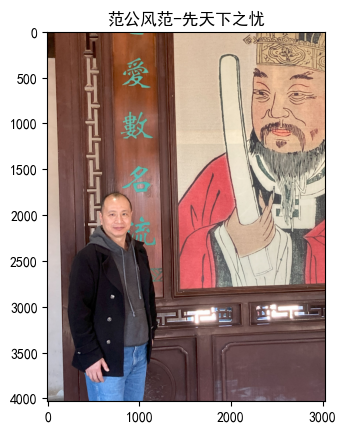

In [8]:
#coding:utf-8 
import matplotlib.pyplot as plt
#import rcParams um chinesische Texte richtig in Matplotlib anzuzeigen
from matplotlib import rcParams

# Setze die chin. Schriftart für den Titel, die in Matpolotlib angezeigt werden kann
rcParams['font.family'] = 'SimHei'  # oder 'Microsoft YaHei'

plt.imshow(xf_im)
plt.title('范公风范-先天下之忧')


Text(0.5, 1.0, 'Steve Jobs Think Big Think Long!')

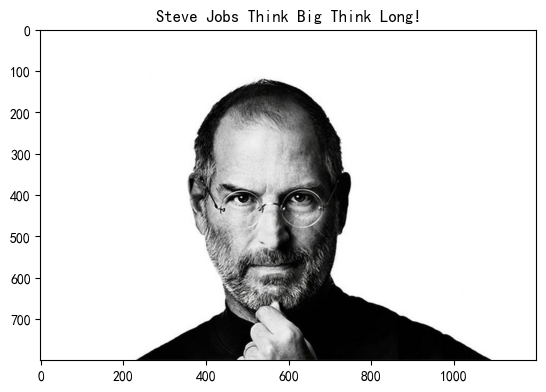

In [9]:
plt.imshow(jobs)
plt.title('Steve Jobs Think Big Think Long!')

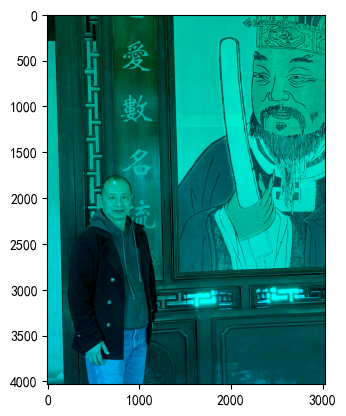

In [10]:
# Setze die roten Farbkanäle auf 0 und erhöhe die grünen Farbkanäle
xf_im[:, :, 0] = 0  # Rote Kanäle auf 0 setzen
xf_im[:, :, 1] = xf_im[:, :, 1] + xf_im[:, :, 0]  # Grüne Kanäle erhöhen
plt.imshow(xf_im) 
#plt.axis('off')  # Achsen ausschalten 


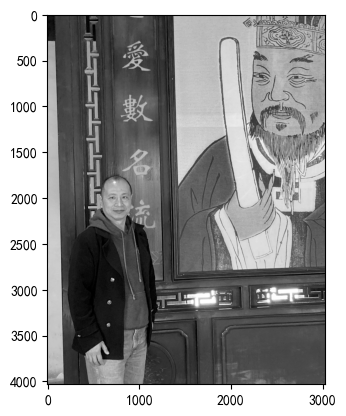

In [11]:
# Manipulation 2: In Graustufen umwandeln
gray_image_array = np.dot(xf_im[..., :3], [0.2989, 0.5870, 0.1140])  # Graustufenformel
gray_image_array = np.clip(gray_image_array, 0, 255).astype(np.uint8)  # Werte auf 0-255 beschränken
plt.imshow(gray_image_array, cmap='gray')

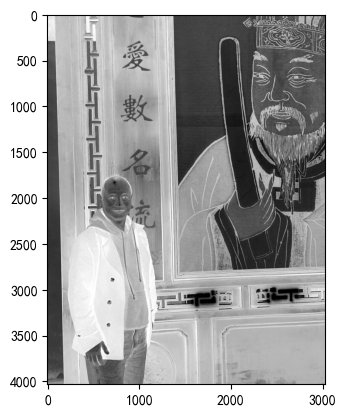

In [12]:
# Manipulation 3: Bild invertieren
inverted_image_array = 255 - gray_image_array  # Invertiere die Farben
plt.imshow(inverted_image_array,cmap='gray')  # Invertiertes Bild anzeigen

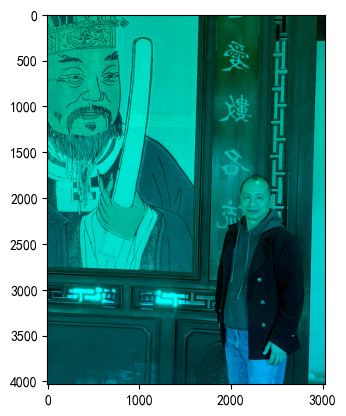

In [13]:
#WE CAN REVERSE IT ..
plt.imshow(xf_im[:,::-1])

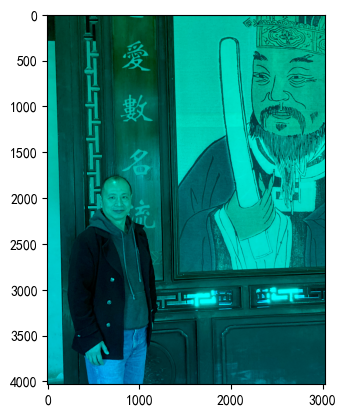

In [14]:

plt.imshow(xf_im[1:,2:]) #crop the image

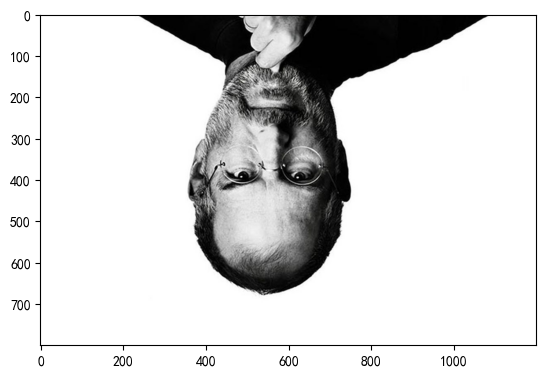

In [15]:
plt.imshow(jobs[::-1]) #rotation

In [ ]:
plt.imshow(xf_im[::2,::2]) # reducing the size of image

In [ ]:
#photo_change = np.where(xf_im > 22,255,0)
photo_change = np.where(xf_im > 90,200,0)
plt.imshow(photo_change)

In [ ]:
plt.imshow(xf_im[:,:,0].T) # T- transpose matrix